In [1]:
import os
import sys
import torch
import argparse
import mlflow
import mlflow.pytorch

import pandas as pd
import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig
from TCM import compute_tcm

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
xtrain, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [5]:
mlflow.end_run()
mlflow.set_tracking_uri("file:./mlruns")

experiment_name = "PA-MNIST"
mlflow.set_experiment(experiment_name)

exp = mlflow.get_experiment_by_name(experiment_name)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", exp.name)
print("Experiment ID:", exp.experiment_id)

run_name = f"PA-GenRKM-{opt.max_epochs}-{opt.h_dim}-{opt.capacity}-{ct}"

Tracking URI: file:./mlruns
Experiment: PA-MNIST
Experiment ID: 760166840825326475


/opt/anaconda3/envs/MT-Dev2/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [6]:
epsilon = 0.2

In [7]:
def kPCA(X, Y, eps=1e-6):
    a = X @ X.T + Y @ Y.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [8]:
def rkm_loss(output1, X, output2, Y):
    h, s = kPCA(output1, output2)
    U = torch.mm(output1.t(), h)
    V = torch.mm(output2.t(), h)

    x_tilde = net3(torch.mm(h, U.t()))
    y_logits = net4(torch.mm(h, V.t()))

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), h.t())) + torch.trace(
         torch.mm(torch.mm(output2, V), h.t()))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), h.t())))
    f3 = 0.5 * (torch.trace(torch.mm(U.t(), U)) + torch.trace(torch.mm(V.t(), V)))

    # Reconstruction losses
    mse = torch.nn.MSELoss()
    img_loss = mse(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim))

    ce = torch.nn.BCEWithLogitsLoss()
    lbl_loss = ce(y_logits.view(-1, 10), Y.view(-1, 10))

    f4 = img_loss + lbl_loss

    loss = -f1 + f3 + f2 + 0.5 * (-f1 + f3 + f2) ** 2 + opt.c_accu * f4
    return loss

In [9]:
net1 = Net1(opt).double().to(opt.device)
net2 = Net2(opt).double().to(opt.device)
net3 = Net3(opt).double().to(opt.device)
net4 = Net4(opt).double().to(opt.device)

In [10]:
params = list(net1.parameters()) + list(net3.parameters()) + list(net2.parameters()) + list(net4.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)
loss_history = []

In [11]:
# l_cost = 6  # Costs from where checkpoints will be saved
# t = 1
# cost = np.inf  # Initialize cost
# start = datetime.now()
# global_step = 0

# while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
#     avg_loss = 0
#     for i, (datax, datay) in enumerate(xtrain):
#         if i < math.ceil(opt.N / opt.mb_size):
#             # Create FGSM Batch
#             data_x_attack = datax.clone().detach().requires_grad_(True).to(opt.device)
#             optimizer.zero_grad()

#             output_x = net1(data_x_attack)
#             output_y = net2(datay.to(opt.device))
            

#             datax, datay = datax.to(opt.device), datay.to(opt.device)
#             output1 = net1(datax)
#             output2 = net2(datay)

#             loss_attack = rkm_loss(output_x, data_x_attack, output_y, datay.to(opt.device))
#             loss_attack.backward()

#             adv_data_x = data_x_attack + epsilon * data_x_attack.grad.sign()
#             adv_data_x = torch.clamp(adv_data_x, 0, 1).detach()

#             optimizer.zero_grad()
#             output1 = net1(adv_data_x)
#             output2 = net2(datay)

#             loss_adv = rkm_loss(output1, adv_data_x, output2, datay)
#             loss_adv.backward()

#             torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)  # Gradient clipping

#             optimizer.step()

#             global_step += 1
#             avg_loss += loss_adv.detach().cpu().numpy()

#             mlflow.log_metric("train_batch_loss", loss_adv.item(), step=global_step)
#             mlflow.log_metric("attack_batch_loss", loss_attack.item(), step=global_step)
#             mlflow.log_metric("learning_rate", optimizer.param_groups[0]["lr"], step=global_step)
#         else:
#             break
#     cost = avg_loss

#     # Remember lowest cost and save checkpoint
#     is_best = cost < l_cost
#     l_cost = min(cost, l_cost)

#     dirs.save_checkpoint({
#         'epochs': t + 1,
#         'net1_state_dict': net1.state_dict(),
#         'net3_state_dict': net3.state_dict(),
#         'net2_state_dict': net2.state_dict(),
#         'net4_state_dict': net4.state_dict(),
#         'l_cost': l_cost,
#         'optimizer': optimizer.state_dict()}, is_best)

#     mlflow.log_metric("train_epoch_loss", float(cost), step=t)
#     t += 1
    
# print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

In [12]:
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net1.load_state_dict(sd_mdl['net1_state_dict'])
#     net3.load_state_dict(sd_mdl['net3_state_dict'])
#     net2.load_state_dict(sd_mdl['net2_state_dict'])
#     net4.load_state_dict(sd_mdl['net4_state_dict'])

# U, V, h, s = final_compute(opt, net1, net2, kPCA)

In [13]:
# torch.save({'net1': net1,
#             'net3': net3,
#             'net2': net2,
#             'net4': net4,

#             'net1_state_dict': net1.state_dict(),
#             'net3_state_dict': net3.state_dict(),
#             'net2_state_dict': net2.state_dict(),
#             'net4_state_dict': net4.state_dict(),

#             'datax': datax,
#             'datay': datay,

#             'h': h,
#             'opt': opt, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

In [14]:
model = torch.load('out/Attack-Final-2V.tar', weights_only=False)

net1 = model['net1']
net2 = model['net2']
net3 = model['net3']
net4 = model['net4']

datax = model['datax']
datay = model['datay']

U_x = model['U']
V_y = model['V']

## Evaluation

In [15]:
all_im_en = []
all_la_en = []

all_data_im = []
all_data_la = []

all_im_de = []
adv_losses = []

loss = torch.nn.MSELoss()

with torch.no_grad():
    for datax, datay in xtest:
        datax = datax.to(opt.device)
        datay = datay.to(opt.device)

        x_en = net1(datax)
        y_en = net2(datay)

        all_im_en.append(x_en)
        all_la_en.append(y_en)

        all_data_im.append(datax)
        all_data_la.append(datay)

In [16]:
all_im_en = torch.cat(all_im_en, dim=0)[:1000]
all_la_en = torch.cat(all_la_en, dim=0)[:1000]

all_data_im = torch.cat(all_data_im, dim=0)[:1000]
all_data_la = torch.cat(all_data_la, dim=0)[:1000]

In [17]:
with torch.no_grad():
    for i in range(10):
        start, stop = i * 100, (i + 1) * 100

        h_test, _ = kPCA(all_im_en[start:stop], all_la_en[start:stop])

        U_test = all_im_en[start:stop].t() @ h_test
        V_test = all_la_en[start:stop].t() @ h_test

        # U_test = U_x
        # V_test = V_y

        x_im_tilde_test = net3(h_test @ U_test.T)
        y_la_tilde_test = net4(h_test @ V_test.T)

        all_im_de.append(x_im_tilde_test)

        adv_losses.append(loss(x_im_tilde_test.view(-1, ipVec_dim), all_data_im[start:stop].view(-1, ipVec_dim)).item())

In [18]:
adv_losses

[0.008945206520677429,
 0.00884879620099145,
 0.009782373566164565,
 0.010235220583133723,
 0.008806600631215291,
 0.00941167921507504,
 0.009624320812414358,
 0.010067230257255819,
 0.009204657655429832,
 0.009652509728842113]

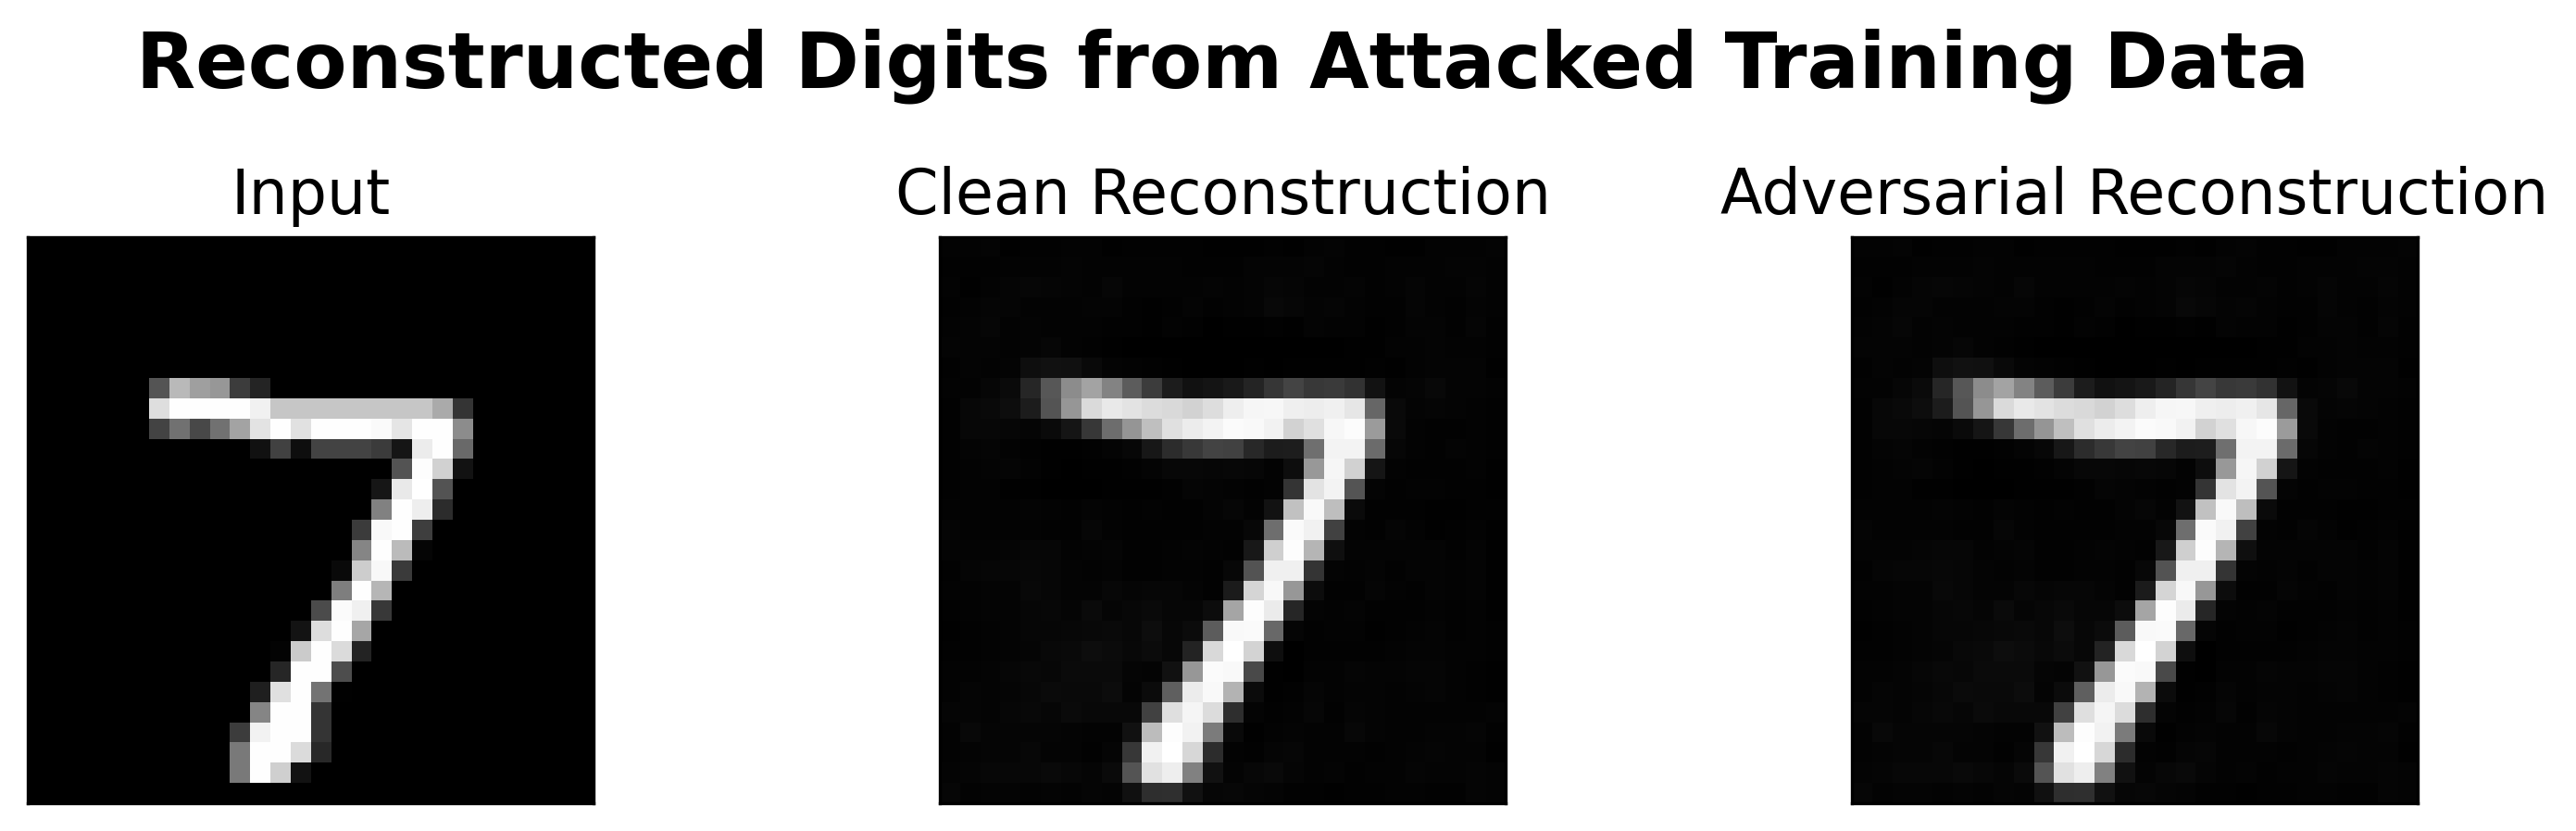

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

# Column titles
axes[0].set_title('Input', fontsize=16)
axes[1].set_title('Clean Reconstruction', fontsize=16)
axes[2].set_title('Adversarial Reconstruction', fontsize=16)

# Images
axes[0].imshow(all_data_im[0].permute(1, 2, 0).cpu().numpy(), cmap='gray')
axes[1].imshow(all_im_de[0][0].permute(1, 2, 0).cpu().numpy(), cmap='gray')
axes[2].imshow(all_im_de[0][0].permute(1, 2, 0).cpu().numpy(), cmap='gray')

# Remove ticks
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)

plt.suptitle('Reconstructed Digits from Attacked Training Data', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/Attack-C-Visualization.png', bbox_inches='tight', dpi=300)
plt.show()

In [20]:
i_val = 10

In [21]:
r = pd.DataFrame({
    'model': ['1V'] * i_val,
    'image_attack': [True] * i_val,
    'sketch_attack': [False] * i_val,

    'Clean_IM_Loss': [None] * i_val,
    'ADV_IM_Loss': adv_losses,
    'Clean_SK_Loss': [None] * i_val,
    'FGSM_SK_Loss': [None] * i_val,
    'Clean_LA_Loss': [None] * i_val,
    'FGSM_LA_Loss': [None] * i_val
})

results_file = 'Attack-C-Results.csv'
if os.path.exists(results_file):
    r.to_csv(results_file, mode='a', header=False, index=False)
else:
    r.to_csv(results_file, index=False)